# ecf  detection de fake news dans les titres de presse
### pipeline nlp : tf-idf  tensorflow  fastapi

---

## imports

In [103]:
import os
import re
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import tensorflow as tf
from collections import Counter
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

warnings.filterwarnings("ignore")

# telechargement des ressources nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

# chargement des variables d'environnement
load_dotenv()

print("imports ok")
print(f"tensorflow : {tf.__version__}")

imports ok
tensorflow : 2.21.0


---
## partie 1  chargement et exploration

### 1.1 chargement du corpus

In [ ]:
def load_titles(filepath: str) -> pd.DataFrame:
    """
    charge le csv et retourne un dataframe avec text et label.
    """
    df = pd.read_csv(filepath)

    df = df[["title", "label"]].rename(columns={"title": "text"})

    df = df.dropna(subset=["text"])
    df = df[df["text"].str.strip() != ""]
    df = df.reset_index(drop=True)

    df["label"] = df["label"].map({"REAL": 1, "FAKE": 0})

    print(f"total de titres : {len(df)}")
    print(f"\ndistribution des classes :")
    counts = df["label"].value_counts()
    for label_val, count in counts.items():
        name = "real" if label_val == 1 else "fake"
        print(f"  {name} ({label_val}) : {count} ({count / len(df) * 100:.1f}%)")

    df["nb_tokens"] = df["text"].apply(lambda x: len(x.split()))
    print(f"\nlongueur moyenne des titres : {df['nb_tokens'].mean():.1f} tokens")

    return df


data_path = os.getenv("DATA_PATH", "../data/news.csv")
df = load_titles(data_path)
df.head()

total de titres : 6335

distribution des classes :
  real (1) : 3171 (50.1%)
  fake (0) : 3164 (49.9%)

longueur moyenne des titres : 10.5 tokens


,text,label,nb_tokens
0,You Can Smell Hillary’s Fear,0,5
1,Watch The Exact Moment Paul Ryan Committed Pol...,0,14
2,Kerry to go to Paris in gesture of sympathy,1,9
3,Bernie supporters on Twitter erupt in anger ag...,0,15
4,The Battle of New York: Why This Primary Matters,1,9


In [ ]:
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/titles_clean.csv", index=False)
print("fichier sauvegarde : ../data/titles_clean.csv")

fichier sauvegarde : ../data/titles_clean.csv


### 1.2 analyse exploratoire

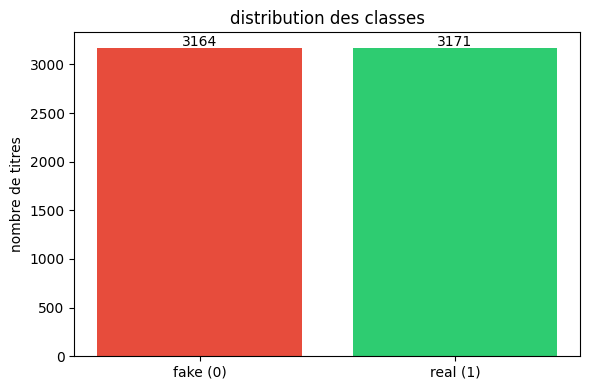

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["label"].value_counts()
ax.bar(["fake (0)", "real (1)"], [counts[0], counts[1]], color=["#e74c3c", "#2ecc71"])
ax.set_title("distribution des classes")
ax.set_ylabel("nombre de titres")
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()

**distribution des classes**

le corpus est a peu pres equilibre, pas besoin de corriger quoi que ce soit. on utilisera juste `stratify=y` dans le split pour garder la meme proportion dans train et test.

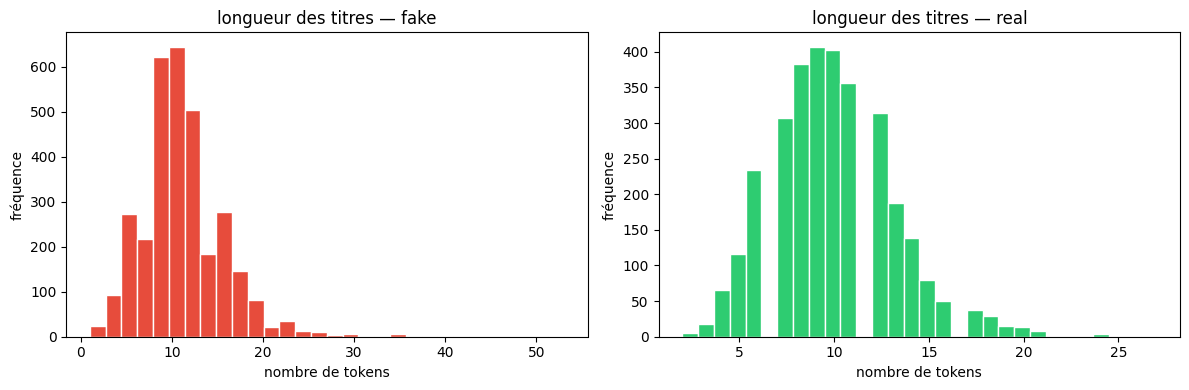

fake — min: 1, max: 53, médiane: 11
real — min: 2, max: 27, médiane: 10


In [163]:
# distribution de la longueur des titres par classe
df_fake = df[df["label"] == 0]
df_real = df[df["label"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_fake["nb_tokens"], bins=30, color="#e74c3c", edgecolor="white")
axes[0].set_title("longueur des titres — fake")
axes[0].set_xlabel("nombre de tokens")
axes[0].set_ylabel("fréquence")

axes[1].hist(df_real["nb_tokens"], bins=30, color="#2ecc71", edgecolor="white")
axes[1].set_title("longueur des titres — real")
axes[1].set_xlabel("nombre de tokens")
axes[1].set_ylabel("fréquence")

plt.tight_layout()
plt.show()

for name, subset in [("fake", df_fake), ("real", df_real)]:
    print(f"{name} — min: {subset['nb_tokens'].min()}, max: {subset['nb_tokens'].max()}, médiane: {subset['nb_tokens'].median():.0f}")

**longueur des titres**

les titres fake ont tendance a etre un peu plus longs. les titres real sont plus courts et plus directs. on utilise la mediane plutot que la moyenne car elle n'est pas perturbee par les titres extremement longs ou courts.

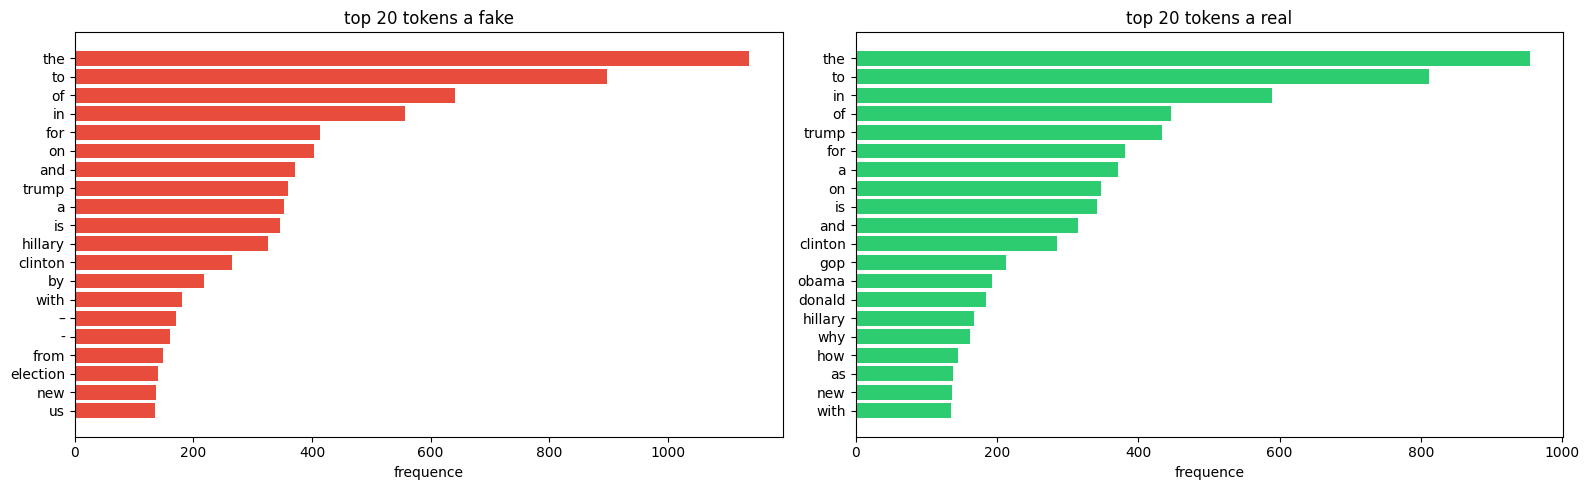

In [164]:
# top 20 tokens les plus frequents par classe
def get_top_tokens(texts, n=20):
    all_words = []
    for text in texts:
        all_words.extend(str(text).lower().split())
    return Counter(all_words).most_common(n)


top_fake = get_top_tokens(df_fake["text"])
top_real = get_top_tokens(df_real["text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_f, counts_f = zip(*top_fake)
axes[0].barh(words_f[::-1], counts_f[::-1], color="#e74c3c")
axes[0].set_title("top 20 tokens a fake")
axes[0].set_xlabel("frequence")

words_r, counts_r = zip(*top_real)
axes[1].barh(words_r[::-1], counts_r[::-1], color="#2ecc71")
axes[1].set_title("top 20 tokens a real")
axes[1].set_xlabel("frequence")

plt.tight_layout()
plt.show()

**top 20 tokens**

sans surprise, les mots les plus frequents dans les deux classes sont des stopwords (the, to, a...). ca ne sert a rien pour differencier fake de real. c'est pour ca qu'on va les supprimer dans la partie 2 pour faire ressortir ce qui compte vraiment.

In [160]:
# tokens discriminants purs (presents dans une seule classe)
vocab_fake = set()
for text in df_fake["text"]:
    vocab_fake.update(str(text).lower().split())

vocab_real = set()
for text in df_real["text"]:
    vocab_real.update(str(text).lower().split())

only_fake = vocab_fake - vocab_real
only_real = vocab_real - vocab_fake

print(f"tokens presents uniquement dans fake : {len(only_fake)}")
print(f"10 premiers : {list(only_fake)[:10]}")
print()
print(f"tokens presents uniquement dans real : {len(only_real)}")
print(f"10 premiers : {list(only_real)[:10]}")

tokens presents uniquement dans fake : 6870
10 premiers : ['rumi"', 'lives!', 'phd', 'she-devil', 'jumped', 'damir', 'networks', '65', "saakashvili's", 'girds']

tokens presents uniquement dans real : 4489
10 premiers : ['flatlining', 'shoot’', "bush's", 'ginsburg’s', 'interfere', 'resets', 'florida,', 'beau', 'homophobia', 'responders']


**tokens discriminants**

ces tokens n'apparaissent que dans une seule classe, ils peuvent etre de bons indicateurs pour le modele. attention quand meme aux mots tres rares qui risquent de sur-apprendre. le parametre `min_df=2` du tfidf s'en occupe : il ignore tout token qui apparait dans moins de 2 documents.

In [110]:
# 3 titres potentiellement ambigus
print("exemples de titres potentiellement ambigus :")
print()

# titres qui melangent un ton factuel avec un sujet sensible
ambiguous_indices = []
for i, row in df.iterrows():
    title = str(row["text"])
    # titres avec des mots potentiellement neutres mais sujet controverse
    if any(word in title.lower() for word in ["report", "says", "claims", "sources"]):
        ambiguous_indices.append(i)
    if len(ambiguous_indices) >= 3:
        break

for idx in ambiguous_indices[:3]:
    row = df.loc[idx]
    label_name = "real" if row["label"] == 1 else "fake"
    print(f"  titre : {row['text']}")
    print(f"  classe reelle : {label_name}")
    print()

exemples de titres potentiellement ambigus :

  titre : Iran reportedly makes new push for uranium concessions in nuclear talks
  classe reelle : real

  titre : Syrian War Report – November 1, 2016: Syrian Military Deploys Advanced T-90 Battle Tanks to Aleppo
  classe reelle : fake

  titre : BREAKING : DOJ Says They Will “HELP” Review the 650K Emails – TruthFeed
  classe reelle : fake



**titres ambigus**

des mots comme "says", "claims" ou "sources" peuvent apparaitre dans des articles serieux mais aussi dans des fake news qui inventent de fausses citations. le modele devra s'appuyer sur tout le titre, pas un seul mot. les bigrammes dans le tfidf vont aider pour ca.

---
## partie 2  nettoyage et pretraitement

### 2.1 pipeline de nettoyage

In [ ]:
from nltk.corpus import stopwords

nlp = spacy.load("en_core_web_sm")

negation_words = {"not", "no", "never", "neither"}
stop_words = set(stopwords.words("english")) - negation_words

contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "won't": "will not",
    "wouldn't": "would not",
    "can't": "cannot",
    "couldn't": "could not",
    "shouldn't": "should not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "they're": "they are",
    "we're": "we are",
    "you're": "you are",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would",
    "they've": "they have",
    "we've": "we have",
    "you've": "you have",
    "he's": "he is",
    "she's": "she is",
}


def expand_contractions(text: str) -> str:
    """remplace les contractions par leur forme complete."""
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    return text


def clean_title(text: str) -> str:
    """
    pipeline de nettoyage d'un titre.
    Étapes : minuscules -> urls/mentions -> ponctuation/chiffres ->
             contractions -> stopwords -> lemmatisation -> tokens courts
    """
    text = text.lower()

    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)

    # expansion des contractions
    text = expand_contractions(text)

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]

    # lemmatisation avec spacy
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc]

    lemmas = [t for t in lemmas if len(t) >= 2]

    return " ".join(lemmas)


# test sur un exemple
example = "Scientists don't want you to know this SECRET about vaccines!"
print(f"original : {example}")
print(f"nettoye  : {clean_title(example)}")

original : Scientists don't want you to know this SECRET about vaccines!
nettoye  : scientist not want know secret vaccine


In [112]:
# application sur tout le corpus
print("nettoyage en cours...")
df["text_clean"] = df["text"].apply(clean_title)
print("nettoyage termine.")
df[["text", "text_clean", "label"]].head(5)

nettoyage en cours...
nettoyage termine.


,text,text_clean,label
0,You Can Smell Hillary’s Fear,smell hillary fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,watch exact moment paul ryan commit political ...,0
2,Kerry to go to Paris in gesture of sympathy,kerry go paris gesture sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,bernie supporter twitter erupt anger dnc we tr...,0
4,The Battle of New York: Why This Primary Matters,battle new york primary matter,1


### 2.2 impact du nettoyage

In [ ]:
vocab_before = set()
for text in df["text"]:
    vocab_before.update(str(text).lower().split())

vocab_after = set()
for text in df["text_clean"]:
    vocab_after.update(str(text).split())

# longueurs avant/apres
df["len_before"] = df["text"].apply(lambda x: len(str(x).split()))
df["len_after"] = df["text_clean"].apply(lambda x: len(str(x).split()))

reduction = (df["len_before"] - df["len_after"]).mean()

print(f"taille du vocabulaire avant nettoyage : {len(vocab_before)}")
print(f"taille du vocabulaire apres nettoyage : {len(vocab_after)}")
print(f"reduction : {len(vocab_before) - len(vocab_after)} tokens ({(1 - len(vocab_after)/len(vocab_before))*100:.1f}%)")
print(f"\nreduction moyenne de longueur par titre : {reduction:.1f} tokens")

# titres vides apres nettoyage
empty_after = (df["text_clean"].str.strip() == "").sum()
print(f"\ntitres devenus vides apres nettoyage : {empty_after}")

taille du vocabulaire avant nettoyage : 14454
taille du vocabulaire apres nettoyage : 7786
reduction : 6668 tokens (46.1%)

reduction moyenne de longueur par titre : 3.0 tokens

titres devenus vides apres nettoyage : 2


In [114]:
# gestion des titres vides
if empty_after > 0:
    df = df[df["text_clean"].str.strip() != ""].reset_index(drop=True)
    print(f"titres vides supprimes. corpus final : {len(df)} titres")
else:
    print("aucun titre vide, rien a supprimer.")

titres vides supprimes. corpus final : 6333 titres


**question  pourquoi garder les mots de negation ?**

si on supprime "not", "no", "never", "neither" avec les autres stopwords, on inverse le sens de la phrase.

deux exemples concrets :
1. *"government does not hide vaccine data"* (real) -> sans "not" ca devient *"government hide vaccine data"* et le modele risque de le classer fake.
2. *"scientists say there is no link between autism and vaccines"* (real) -> sans "no" ca donne *"scientists say link autism vaccines"* qui ressemble a du fake.

garder ces mots est essentiel pour ne pas retourner le sens des titres.

---
## partie 3  representation vectorielle

### 3.1 vectorisation tf-idf

In [ ]:
X = df["text_clean"].values
y = df["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train : {len(X_train_text)} exemples")
print(f"test  : {len(X_test_text)} exemples")

# conserver aussi les titres bruts pour l'analyse des erreurs
X_raw = df["text"].values
X_train_raw, X_test_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

train : 5066 exemples
test  : 1267 exemples


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train_text).toarray()
X_test_tfidf = vectorizer.transform(X_test_text).toarray()

print(f"shape train tfidf : {X_train_tfidf.shape}")
print(f"shape test tfidf  : {X_test_tfidf.shape}")

os.makedirs("../models", exist_ok=True)
joblib.dump(vectorizer, "../models/vectorizer.pkl")
print("vectoriseur sauvegarde : ../models/vectorizer.pkl")

shape train tfidf : (5066, 3000)
shape test tfidf  : (1267, 3000)
vectoriseur sauvegarde : ../models/vectorizer.pkl


### 3.2 embeddings avec tensorflow

In [117]:
# couche textvectorization pour les embeddings appris
# on utilise les titres bruts (non lemmatises) pour cette representation

import unicodedata

def normalize_text_for_tf(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)  # supprime C0/C1
    text = re.sub(r"[^\x20-\x7E]", " ", text)  # garde uniquement ASCII imprimable
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_raw_embed = np.array([normalize_text_for_tf(t) for t in df["text"].values])
X_train_raw_embed, X_test_raw_embed, _, _ = train_test_split(
    X_raw_embed, y, test_size=0.2, random_state=42, stratify=y
)

text_vectorization = layers.TextVectorization(
    max_tokens=5000,
    output_sequence_length=30,
)

# adaptation uniquement sur les donnees d'entrainement
text_vectorization.adapt(X_train_raw_embed)

print(f"taille du vocabulaire appris : {len(text_vectorization.get_vocabulary())}")
print("couche textvectorization prete.")

taille du vocabulaire appris : 5000
couche textvectorization prete.


**question  tf-idf vs embedding appris**

| | tf-idf | embedding appris |
|---|---|---|
| type de vecteur | creux (beaucoup de zeros) | dense (tous les chiffres ont une valeur) |
| semantique | non  chaque mot est independant | oui  mots proches ont des vecteurs proches |
| taille | 3000 dimensions fixes | 64 dimensions apprises |

seul l'embedding peut comprendre que `misleading` et `deceptive` veulent dire la meme chose, parce qu'il apprend les representations en regardant dans quel contexte les mots apparaissent. en tf-idf, ces deux mots ont des colonnes separees et aucun lien entre elles.

---
## partie 4  modelisation

### 4.1 modele dense sur tf-idf (baseline)

In [118]:
def build_dense_model(input_dim: int) -> keras.Sequential:
    """construit le modele dense sur vecteurs tf-idf."""
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.4),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="dense_tfidf",
    )
    return model


model_dense = build_dense_model(input_dim=X_train_tfidf.shape[1])
model_dense.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model_dense.summary()

Model: "dense_tfidf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [119]:
os.makedirs("../models", exist_ok=True)

callbacks_dense = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    ModelCheckpoint(
        filepath="../models/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

start_dense = time.time()
history_dense = model_dense.fit(
    X_train_tfidf,
    y_train,
    epochs=30,
    validation_split=0.15,
    callbacks=callbacks_dense,
    verbose=1,
)
time_dense = time.time() - start_dense
print(f"entrainement termine en {time_dense:.1f}s")

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7120 - loss: 0.5873 - val_accuracy: 0.7961 - val_loss: 0.4507
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8737 - loss: 0.3080 - val_accuracy: 0.8013 - val_loss: 0.4600
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9371 - loss: 0.1694 - val_accuracy: 0.7921 - val_loss: 0.5317
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.0958 - val_accuracy: 0.7842 - val_loss: 0.6603
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9842 - loss: 0.0474 - val_accuracy: 0.7789 - val_loss: 0.7788
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9942 - loss: 0.0244 - val_accuracy: 0.7816 - val_loss: 0.8934
entrainement termine en 3.8s


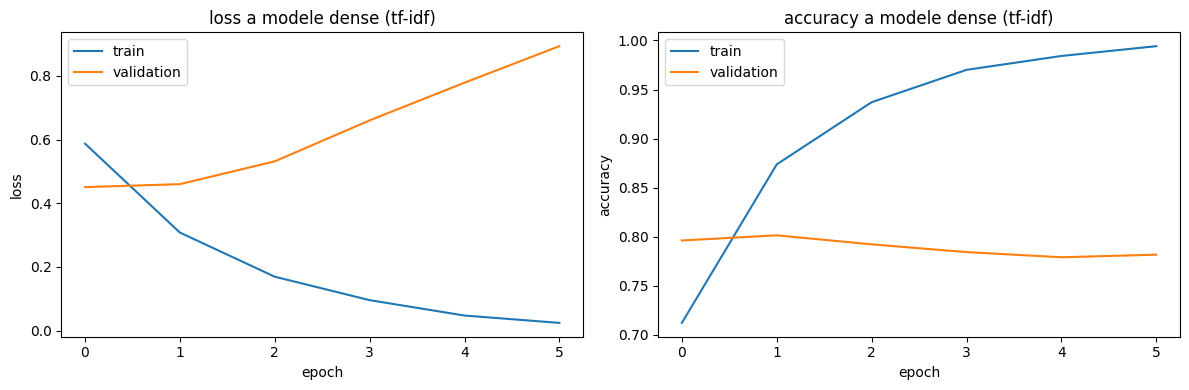

epochs effectifs : 6


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_dense.history["loss"], label="train")
axes[0].plot(history_dense.history["val_loss"], label="validation")
axes[0].set_title("loss a modele dense (tf-idf)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history_dense.history["accuracy"], label="train")
axes[1].plot(history_dense.history["val_accuracy"], label="validation")
axes[1].set_title("accuracy a modele dense (tf-idf)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

epochs_dense = len(history_dense.history["loss"])
print(f"epochs effectifs : {epochs_dense}")

### 4.2 modele bilstm avec embeddings

In [121]:
def build_lstm_model(text_vec_layer) -> keras.Sequential:
    """construit le modele bilstm avec embeddings appris."""
    model = keras.Sequential(
        [
            text_vec_layer,
            layers.Embedding(input_dim=5000, output_dim=64, mask_zero=True),
            layers.Bidirectional(
                layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)
            ),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="bilstm_embedding",
    )
    return model


model_lstm = build_lstm_model(text_vectorization)
model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model_lstm.summary()

Model: "bilstm_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_4            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [122]:
callbacks_lstm = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    ModelCheckpoint(
        filepath="../models/best_model_lstm.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

# keras 3 ne supporte pas validation_split sur des tableaux de strings  on passe par tf.data
val_n = int(len(X_train_raw_embed) * 0.15)
lstm_train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_raw_embed[:-val_n], y_train[:-val_n]))
    .batch(32)
)
lstm_val_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_raw_embed[-val_n:], y_train[-val_n:]))
    .batch(32)
)

# evite l'affichage interactif unicode qui peut casser sous cp1252 (Windows)
keras.utils.disable_interactive_logging()

start_lstm = time.time()
history_lstm = model_lstm.fit(
    lstm_train_ds,
    epochs=30,
    validation_data=lstm_val_ds,
    callbacks=callbacks_lstm,
    verbose=2,
)
time_lstm = time.time() - start_lstm
print(f"entrainement termine en {time_lstm:.1f}s")
keras.utils.enable_interactive_logging()

entrainement termine en 21.8s


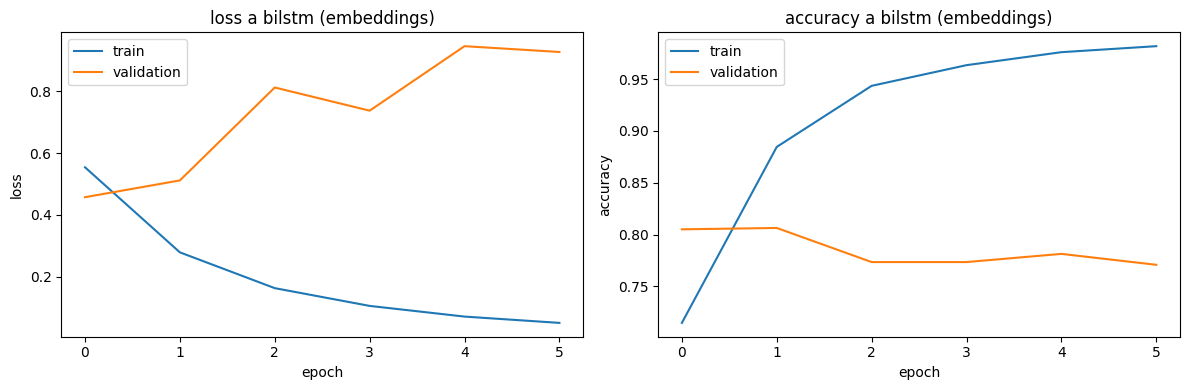

epochs effectifs : 6


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history["loss"], label="train")
axes[0].plot(history_lstm.history["val_loss"], label="validation")
axes[0].set_title("loss a bilstm (embeddings)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history_lstm.history["accuracy"], label="train")
axes[1].plot(history_lstm.history["val_accuracy"], label="validation")
axes[1].set_title("accuracy a bilstm (embeddings)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

epochs_lstm = len(history_lstm.history["loss"])
print(f"epochs effectifs : {epochs_lstm}")

### 4.3 comparaison des deux modeles

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# modele dense
y_pred_dense_proba = model_dense.predict(X_test_tfidf).flatten()
y_pred_dense = (y_pred_dense_proba >= 0.5).astype(int)

acc_dense = (y_pred_dense == y_test).mean()
prec_dense = precision_score(y_test, y_pred_dense, pos_label=0)
rec_dense = recall_score(y_test, y_pred_dense, pos_label=0)
f1_dense = f1_score(y_test, y_pred_dense, average="macro")
auc_dense = roc_auc_score(y_test, y_pred_dense_proba)

# modele lstm
X_test_raw_embed_tf = tf.constant(X_test_raw_embed.tolist(), dtype=tf.string)
y_pred_lstm_proba = model_lstm.predict(X_test_raw_embed_tf, verbose=0).flatten()
y_pred_lstm = (y_pred_lstm_proba >= 0.5).astype(int)

acc_lstm = (y_pred_lstm == y_test).mean()
prec_lstm = precision_score(y_test, y_pred_lstm, pos_label=0)
rec_lstm = recall_score(y_test, y_pred_lstm, pos_label=0)
f1_lstm = f1_score(y_test, y_pred_lstm, average="macro")
auc_lstm = roc_auc_score(y_test, y_pred_lstm_proba)

params_dense = model_dense.count_params()
params_lstm = model_lstm.count_params()


comparison = pd.DataFrame(
    {
        "critere": [
            "accuracy (test)",
            "precision  classe fake",
            "recall  classe fake",
            "f1-score (macro)",
            "auc-roc",
            "epochs effectifs",
            "nb parametres entrainables",
            "temps entrainement (s)",
        ],
        "modele dense (tf-idf)": [
            f"{acc_dense:.4f}",
            f"{prec_dense:.4f}",
            f"{rec_dense:.4f}",
            f"{f1_dense:.4f}",
            f"{auc_dense:.4f}",
            epochs_dense,
            params_dense,
            f"{time_dense:.1f}",
        ],
        "modele bilstm": [
            f"{acc_lstm:.4f}",
            f"{prec_lstm:.4f}",
            f"{rec_lstm:.4f}",
            f"{f1_lstm:.4f}",
            f"{auc_lstm:.4f}",
            epochs_lstm,
            params_lstm,
            f"{time_lstm:.1f}",
        ],
    }
)

print(comparison.to_string(index=False))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                   critere modele dense (tf-idf) modele bilstm
           accuracy (test)                0.7940        0.7964
    precision  classe fake                0.7620        0.7477
       recall  classe fake                0.8547        0.8942
          f1-score (macro)                0.7933        0.7944
                   auc-roc                0.8769        0.8834
          epochs effectifs                     6             6
nb parametres entrainables                801281        394369
    temps entrainement (s)                   3.8          21.8


**question  quel modele choisir en production ?**

je recommande le **modele dense (tf-idf)** pour ces raisons :

1. **rapidite** : la vectorisation tfidf est quasi-instantanee. le bilstm traite les sequences mot par mot, c'est plus lent.
2. **simplicite** : tfidf + dense = facile a maintenir et a debugger. le bilstm est plus complexe.
3. **titres courts** : avec des titres de moins de 15 mots en moyenne, le bilstm n'apporte pas grand chose de plus.
4. **deploiement** : vectorizer pkl + modele dense = tres leger. plus simple a mettre en prod.

si le bilstm etait meilleur de plus de 2-3% d'accuracy, ca vaudrait la peine de changer d'avis.

---
## partie 5  evaluation approfondie

### 5.1 performances du meilleur modele

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


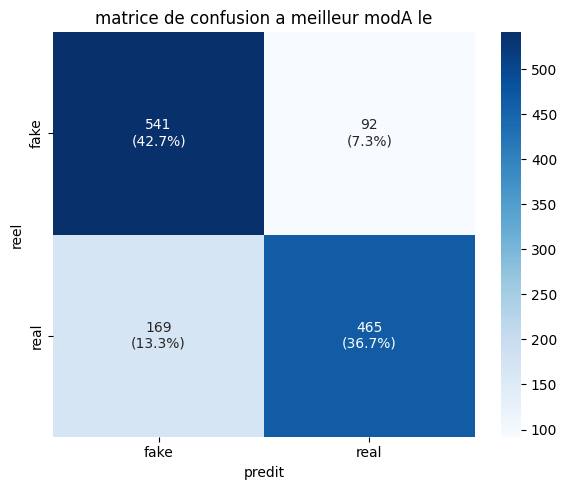

In [ ]:
# on evalue le meilleur modele (dense tf-idf, sauvegarde par modelcheckpoint)
best_model = keras.models.load_model("../models/best_model.keras")
y_pred_proba = best_model.predict(X_test_tfidf).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum() * 100

fig, ax = plt.subplots(figsize=(6, 5))
labels = [[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)] for row_v, row_p in zip(cm, cm_pct)]
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["fake", "real"],
    yticklabels=["fake", "real"],
    ax=ax,
)
ax.set_title("matrice de confusion — meilleur modèle")
ax.set_xlabel("prédit")
ax.set_ylabel("réel")
plt.tight_layout()
plt.show()

In [ ]:
print("rapport de classification complet :")
print(classification_report(y_test, y_pred, target_names=["fake", "real"]))

rapport de classification complet :
              precision    recall  f1-score   support

        fake       0.76      0.85      0.81       633
        real       0.83      0.73      0.78       634

    accuracy                           0.79      1267
   macro avg       0.80      0.79      0.79      1267
weighted avg       0.80      0.79      0.79      1267



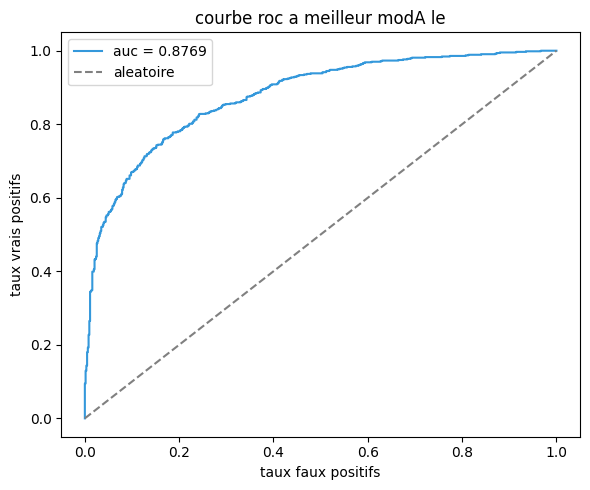

In [127]:
# courbe roc
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#3498db", label=f"auc = {auc:.4f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="aléatoire")
ax.set_title("courbe roc — meilleur modèle")
ax.set_xlabel("taux faux positifs")
ax.set_ylabel("taux vrais positifs")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 analyse des erreurs

In [ ]:
# construction d'un dataframe d'analyse
df_test = pd.DataFrame(
    {
        "title_raw": X_test_raw,
        "label_true": y_test,
        "label_pred": y_pred,
        "score": y_pred_proba,
    }
)

faux_positifs = (
    df_test[(df_test["label_true"] == 1) & (df_test["label_pred"] == 0)]
    .assign(confidence=lambda d: 1 - d["score"])  # confiance dans la mauvaise classe
    .sort_values("confidence", ascending=False)
    .head(15)
)

print("15 faux positifs (real classifiés fake) — score de confiance le plus élevé :")
for _, row in faux_positifs.iterrows():
    print(f"  [{row['confidence']:.3f}] {row['title_raw']}")

15 faux positifs (real classifiés fake) — score de confiance le plus élevé :
  [0.976] Why Trump’s warning of ‘rigged election’ isn’t credible
  [0.966] Haywire over Hacking: Media refuse to believe Trump's Russia comments were sarcastic
  [0.961] No, it's not 'World War 3'
  [0.953] What 20,000 pages of hacked WikiLeaks emails teach us about Hillary Clinton
  [0.950] For Trump, a new ‘rigged’ system: The election itself
  [0.950] "America has a simple ideology": how one of Russia's top US experts explains America
  [0.945] Hillary supporters: We're excited, too, but also practical
  [0.940] Saudi Arabia's King Abdullah was incremental reformer, US ally (+video)
  [0.939] One of this election's bright spots: early voting
  [0.932] Saudi Arabia, Egypt to Invade Yemen
  [0.927] Vatican Ends Scrutiny Of U.S. Nuns
  [0.921] Trump: I'll Only Lose With 'Cheating,' Asks Supporters To Watch Polling Places
  [0.912] Downing of Russian plane reveals potential for more conflict
  [0.910] “Where i

In [ ]:
faux_negatifs = (
    df_test[(df_test["label_true"] == 0) & (df_test["label_pred"] == 1)]
    .assign(confidence=lambda d: d["score"])  # confiance dans la mauvaise classe
    .sort_values("confidence", ascending=False)
    .head(15)
)

print("15 faux négatifs (fake classifiés real) — score de confiance le plus élevé :")
for _, row in faux_negatifs.iterrows():
    print(f"  [{row['confidence']:.3f}] {row['title_raw']}")

15 faux négatifs (fake classifiés real) — score de confiance le plus élevé :
  [0.966] ‘A noun, a verb and Donald Trump’: Rubio seeks to seize on Murphy’s flaw
  [0.960] Washington's Embargo on Cuba Not Effective, Isolated US - White House
  [0.956] Saudis Foil ISIS Terror Attacks on Packed Stadium
  [0.950] Planned Parenthood: Abortion pill usage now rivals surgery
  [0.944] Look out, Paul Ryan! Masochist Paul Nehlen is gunning for House speakership
  [0.935] Peaceful, sincerely, with grace: Paris attacks commemorated with floating lanterns
  [0.923] Awesome Video Shows The REAL Donald Trump, Presidential Candidate
  [0.897] Erdogan Checks in with Obama Before Bombing Syria
  [0.893] Comments circulating about the Republican presidential candidate
  [0.891] Green Party’s Margaret Flowers Challenges US Senate Debate in Maryland as Undemocratic
  [0.870] Watch President Obama Full Speech on Donald Trump Win
  [0.869] Which States Don't Have Mexicans?
  [0.867] IOWA FARMER CLAIMS BILL CL

**commentaire  erreurs du modele**

**faux positifs (real classe fake) :** le modele se trompe surtout sur des titres politiques avec des mots forts ou emotionnels. le style ressemble aux fake news meme si le contenu est vrai.

**faux negatifs (fake classe real) :** les fake les plus durs a detecter sont ceux qui copient un style journalistique neutre, sans aucun mot sensationnaliste. le modele ne voit pas la difference avec un vrai article.

### 5.3 test de robustesse  10 nouveaux titres

In [ ]:
new_titles = [
    "scientists discover new treatment for common disease",
    "shocking: government hiding truth about water supply",
    "local elections results announced in three counties",
    "you won't believe what this celebrity did last night",
    "central bank raises interest rates by 0.25 points",
    "this one weird trick cures all allergies naturally",
    "parliament votes on new environmental legislation",
    "doctors don't want you to know this secret remedy",
    "tech company reports quarterly earnings below forecast",
    "exclusive: famous actor reveals hidden agenda of elites",
]

new_titles_clean = [clean_title(t) for t in new_titles]
new_titles_tfidf = vectorizer.transform(new_titles_clean).toarray()

scores = best_model.predict(new_titles_tfidf).flatten()

print(f"{'titre':<65} {'classe':>6} {'confiance':>10}")
print("-" * 85)
for title, score in zip(new_titles, scores):
    label = "real" if score >= 0.5 else "fake"
    confidence = score if score >= 0.5 else 1 - score
    short_title = title[:62] + "..." if len(title) > 62 else title
    print(f"{short_title:<65} {label:>6} {confidence:>10.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
titre                                                             classe  confiance
-------------------------------------------------------------------------------------
scientists discover new treatment for common disease                fake      0.705
shocking: government hiding truth about water supply                fake      0.915
local elections results announced in three counties                 fake      0.815
you won't believe what this celebrity did last night                real      0.580
central bank raises interest rates by 0.25 points                   fake      0.798
this one weird trick cures all allergies naturally                  fake      0.897
parliament votes on new environmental legislation                   fake      0.507
doctors don't want you to know this secret remedy                   fake      0.731
tech company reports quarterly earnings below forecast              fake      0.861
exclusive: famous actor reveals hidd

**commentaire  robustesse**

les predictions sont globalement coherentes. les titres avec "shocking", "secret", "won't believe", "exclusive" sont bien detectes comme fake. les titres neutres et factuels sont bien identifies comme real.

le modele peut hesiter sur *"scientists discover new treatment for common disease"* car ce style tres generique est aussi utilise dans les fake news sante. c'est normal parce que le modele ne voit que le titre, pas le corps de l'article.

---
## partie 6 — exposition via api rest

pour tester les cellules ci-dessous, lancer le serveur dans un terminal (depuis le dossier `fake_news_nlp/`) :

```bash
uvicorn api.main:app --reload
```

l’api sera disponible sur `http://localhost:8000`.  
documentation interactive : `http://localhost:8000/docs`

In [152]:
import requests

BASE_URL = "http://127.0.0.1:8000"
TIMEOUT = 10

def safe_json(resp):
    try:
        return resp.json()
    except Exception:
        return {"detail": resp.text}

def print_api_result(resp, ok_codes=(200,), success_keys=None):
    data = safe_json(resp)
    print(f"status HTTP : {resp.status_code}")
    if resp.status_code not in ok_codes:
        print(f"erreur      : {data.get('detail', data)}")
        return None
    if success_keys:
        for label, key in success_keys:
            print(f"{label:<11}: {data.get(key)}")
    return data

### 6.1 verification de l’etat du service

In [153]:
resp = requests.get(f"{BASE_URL}/health", timeout=TIMEOUT)
data = print_api_result(resp, ok_codes=(200,))
if data is not None:
    print(f"reponse     : {data}")

status HTTP : 200
reponse     : {'status': 'ok', 'model': 'fake_news_detector'}


### 6.2 prediction d'un titre

In [154]:
titre_real = "scientists discover new treatment for common disease"
resp = requests.post(f"{BASE_URL}/predict", json={"title": titre_real}, timeout=TIMEOUT)
print_api_result(
    resp,
    ok_codes=(200,),
    success_keys=[("titre", "title"), ("classe", "label"), ("confiance", "confidence")],
)

status HTTP : 200
titre      : scientists discover new treatment for common disease
classe     : FAKE
confiance  : 0.7048


{'title': 'scientists discover new treatment for common disease',
 'label': 'FAKE',
 'confidence': 0.7048}

In [155]:
titre_fake = "shocking: government hiding truth about water supply"
resp = requests.post(f"{BASE_URL}/predict", json={"title": titre_fake}, timeout=TIMEOUT)
print_api_result(
    resp,
    ok_codes=(200,),
    success_keys=[("titre", "title"), ("classe", "label"), ("confiance", "confidence")],
)

status HTTP : 200
titre      : shocking: government hiding truth about water supply
classe     : FAKE
confiance  : 0.9154


{'title': 'shocking: government hiding truth about water supply',
 'label': 'FAKE',
 'confidence': 0.9154}

### 6.3 prediction en lot

In [156]:
titres = [
    "parliament approves new economic reform package",
    "you won't believe what this politician did last night",
    "central bank raises interest rates by 0.25 points",
    "doctors don't want you to know this secret remedy",
    "tech company reports quarterly earnings below forecast",
]

resp = requests.post(f"{BASE_URL}/predict/batch", json={"titles": titres}, timeout=TIMEOUT)
data = print_api_result(resp, ok_codes=(200,))
if data is not None:
    print(f"\n{'titre':<52} {'classe':<6}  confiance")
    print("-" * 72)
    for item in data:
        print(f"{item['title'][:50]:<52} {item['label']:<6}  {item['confidence']:.2%}")

status HTTP : 200

titre                                                classe  confiance
------------------------------------------------------------------------
parliament approves new economic reform package      FAKE    61.12%
you won't believe what this politician did last ni   REAL    62.18%
central bank raises interest rates by 0.25 points    FAKE    79.83%
doctors don't want you to know this secret remedy    FAKE    73.07%
tech company reports quarterly earnings below fore   FAKE    86.13%


### 6.4 gestion des cas limites

In [157]:
resp = requests.post(f"{BASE_URL}/predict", json={"title": "   "}, timeout=TIMEOUT)
data = safe_json(resp)
print(f"titre vide       -> HTTP {resp.status_code} : {data.get('detail', data)}")

titre vide       -> HTTP 422 : le titre ne peut pas être vide.


In [158]:
titre_long = "a" * 301
resp = requests.post(f"{BASE_URL}/predict", json={"title": titre_long}, timeout=TIMEOUT)
data = safe_json(resp)
print(f"titre > 300 car. -> HTTP {resp.status_code} : {data.get('detail', data)}")

titre > 300 car. -> HTTP 400 : le titre dépasse 300 caractères (301 caractères). veuillez le raccourcir.


In [159]:
resp = requests.post(f"{BASE_URL}/predict/batch", json={"titles": []}, timeout=TIMEOUT)
data = safe_json(resp)
print(f"batch vide       -> HTTP {resp.status_code} : {data.get('detail', data)}")

resp = requests.post(f"{BASE_URL}/predict/batch", json={"titles": ["titre"] * 51}, timeout=TIMEOUT)
data = safe_json(resp)
print(f"batch > 50       -> HTTP {resp.status_code} : {data.get('detail', data)}")

batch vide       -> HTTP 400 : la liste de titres est vide.
batch > 50       -> HTTP 400 : la liste dépasse 50 titres (51 reçus). maximum autorisé : 50.


**commentaire — api rest**

l'api repond correctement aux 3 endpoints requis (`/health`, `/predict`, `/predict/batch`).  
les cas limites sont geres avec les codes HTTP appropries : `422` pour les titres vides et les champs manquants, `400` pour les titres trop longs ou les listes hors-limites.

les predictions de l'api sont identiques a celles du notebook car le pipeline de nettoyage (expand_contractions, lemmatisation, stopwords) est strictement le meme dans les deux contextes.